# VOLUME

## Imports & Paths

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis

PATH_DATA  = r"C:/Users/nhokk/Downloads/FINAL DATASET.xlsx"
PATH_PMIME = r"C:/Users/nhokk/Downloads/PMIME_features_for_python.csv"
PATH_CGCI  = r"C:/Users/nhokk/Downloads/cgci_node_scores_top20vol_2021_2024.csv"

## Load raw data + basic cleaning

In [3]:
import pandas as pd
import numpy as np

file_path = "FINAL DATASET.xlsx"
df_raw = pd.read_excel(file_path)

df = df_raw.copy()
df.columns = [c.lower() for c in df.columns]

df["time"]   = pd.to_datetime(df["time"])
df["symbol"] = df["symbol"].astype(str).str.upper().str.strip()

# Keep data from 2021-03-24 onward
df = df[df["time"] >= "2021-03-24"].copy()

# Remove ROS
df = df[df["symbol"] != "ROS"].copy()

# Remove duplicate observations (time, symbol)
df = df.sort_values(["time", "symbol"]) \
       .drop_duplicates(subset=["time", "symbol"], keep="first") \
       .copy()

print("✅ Clean df shape:", df.shape)
print("✅ Time range:", df["time"].min(), "→", df["time"].max())
print("✅ Number of symbols:", df["symbol"].nunique())

# FIXED (20 STOCKS)
top20_symbols = [
    'SHB', 'HPG', 'SSI', 'VPB', 'STB', 'MBB', 'NVL', 'TCB', 'TPB', 'PDR', 'TCH', 'CTG', 'ACB', 'HDB', 'LPB', 'VRE', 'VHM', 'EIB', 'MWG', 'VIB'
]

# Check presence in df
present = sorted([s for s in top20_symbols if s in df["symbol"].unique()])
missing = sorted([s for s in top20_symbols if s not in df["symbol"].unique()])

print("\n📌 Fixed universe (20 stocks):")
print(top20_symbols)
print("→ Total:", len(top20_symbols))

print("\n✅ Present in df:", present)
print("❌ Missing in df:", missing)


# RETURNS & VOLATILITY
prices = df.pivot(index="time", columns="symbol", values="close").sort_index()
log_returns = np.log(prices).diff().dropna(how="all")

# Restrict to fixed universe (robust, no KeyError)
logret_stocks = log_returns.reindex(columns=top20_symbols).copy()

# Volatility (std of daily log-returns)
vol_stats = logret_stocks.std(ddof=1, skipna=True).sort_values(ascending=False)

print("\n📊 Volume ranking (fixed universe):")
print(vol_stats)

✅ Clean df shape: (47475, 9)
✅ Time range: 2021-03-24 00:00:00 → 2025-11-10 00:00:00
✅ Number of symbols: 41

📌 Fixed universe (20 stocks):
['SHB', 'HPG', 'SSI', 'VPB', 'STB', 'MBB', 'NVL', 'TCB', 'TPB', 'PDR', 'TCH', 'CTG', 'ACB', 'HDB', 'LPB', 'VRE', 'VHM', 'EIB', 'MWG', 'VIB']
→ Total: 20

✅ Present in df: ['ACB', 'CTG', 'EIB', 'HDB', 'HPG', 'LPB', 'MBB', 'MWG', 'NVL', 'PDR', 'SHB', 'SSI', 'STB', 'TCB', 'TCH', 'TPB', 'VHM', 'VIB', 'VPB', 'VRE']
❌ Missing in df: []

📊 Volume ranking (fixed universe):
symbol
TCH    0.029711
PDR    0.027269
SSI    0.026762
NVL    0.026630
EIB    0.025280
LPB    0.024593
SHB    0.024236
STB    0.024117
VRE    0.023258
MWG    0.022116
HPG    0.021542
TPB    0.021524
VHM    0.021011
TCB    0.020692
VPB    0.020691
VIB    0.020378
CTG    0.020348
HDB    0.019879
MBB    0.019399
ACB    0.017055
dtype: float64


## Technical features

In [4]:
prices = df.pivot(index="time", columns="symbol", values="close").sort_index()
prices = prices[top20_symbols].copy()
log_p = np.log(prices)

ret1 = log_p.diff().add_prefix("ret1_")
ret5 = (log_p.shift(-5) - log_p).add_prefix("y5_")   # TARGET (forward 5d log-return)

mom5  = log_p.diff(5).add_prefix("mom5_")
mom10 = log_p.diff(10).add_prefix("mom10_")
mom20 = log_p.diff(20).add_prefix("mom20_")

ma7  = ret1.rolling(7).mean().add_prefix("ma7_")
ma14 = ret1.rolling(14).mean().add_prefix("ma14_")
ma21 = ret1.rolling(21).mean().add_prefix("ma21_")

vol7  = ret1.rolling(7).std().add_prefix("vol7_")
vol14 = ret1.rolling(14).std().add_prefix("vol14_")
vol21 = ret1.rolling(21).std().add_prefix("vol21_")

vol_ratio = (vol7 / (vol21 + 1e-8))
vol_ratio.columns = [c.replace("vol7_", "volratio_") for c in vol_ratio.columns]

def rolling_apply(df_in, w, func, pre):
    out = pd.DataFrame(index=df_in.index, columns=df_in.columns, dtype="float64")
    for c in df_in.columns:
        out[c] = df_in[c].rolling(w).apply(func, raw=False)
    return out.add_prefix(pre)

skew7  = rolling_apply(ret1, 7,  skew,     "skew7_")
skew14 = rolling_apply(ret1, 14, skew,     "skew14_")
kurt7  = rolling_apply(ret1, 7,  kurtosis, "kurt7_")
kurt14 = rolling_apply(ret1, 14, kurtosis, "kurt14_")

In [5]:
# volume features
df_vol = df[df["volume"] > 0].copy().sort_values(["symbol","time"])
df_vol["log_volume"] = np.log(df_vol["volume"])
df_vol["log_vol_return"] = df_vol.groupby("symbol")["log_volume"].diff()

vol_mat = df_vol.pivot(index="time", columns="symbol", values="log_vol_return")
vol_mat = vol_mat[top20_symbols].reindex(prices.index).add_prefix("volret_")

vol_raw = df_vol.pivot(index="time", columns="symbol", values="volume")
vol_raw = vol_raw[top20_symbols].reindex(prices.index)

vol_ma7  = vol_raw.rolling(7).mean().add_prefix("volma7_")
vol_ma14 = vol_raw.rolling(14).mean().add_prefix("volma14_")
vol_std7 = vol_raw.rolling(7).std().add_prefix("volstd7_")

# order matrix (nếu có)
order_mat = None
if "order" in df.columns:
    order_mat = df.pivot(index="time", columns="symbol", values="order")
    order_mat = order_mat[top20_symbols].reindex(prices.index).add_prefix("ord_")

# usdreturn (nếu có)
usd_series = None
if "usdreturn" in df.columns:
    usd_series = df.groupby("time")["usdreturn"].first().reindex(prices.index).rename("usdreturn")

## Load causal features (PMIME + CGCI), merge, broadcast by day

In [6]:
pmime = pd.read_csv(PATH_PMIME)
cgci  = pd.read_csv(PATH_CGCI)

pmime["symbol"] = pmime["symbol"].astype(str).str.upper()
cgci["symbol"]  = cgci["symbol"].astype(str).str.upper()

# chỉ lấy các mã thuộc top20
pmime = pmime[pmime["symbol"].isin(top20_symbols)].copy()
cgci  = cgci[cgci["symbol"].isin(top20_symbols)].copy()

# merge 2 bảng theo symbol
causal = pd.merge(pmime, cgci, on="symbol", how="outer")

# fill missing (phòng trường hợp thiếu mã ở pmime)
for c in causal.columns:
    if c != "symbol":
        causal[c] = pd.to_numeric(causal[c], errors="coerce")
causal = causal.fillna(0)

print("✅ Causal table (symbol-level):", causal.shape)
print(causal.head())

# broadcast to daily matrix
causal_index = prices.index

causal_wide_list = []
feat_cols = [c for c in causal.columns if c != "symbol"]

for f in feat_cols:
    s = causal.set_index("symbol")[f].reindex(top20_symbols)
    wide = pd.DataFrame(
        np.tile(s.values, (len(causal_index), 1)),
        index=causal_index,
        columns=[f"{f}_{sym}" for sym in top20_symbols]
    )
    causal_wide_list.append(wide)

causal_wide = pd.concat(causal_wide_list, axis=1)
# shift 1 ngày để “an toàn” chống leak theo thời gian
causal_wide = causal_wide.shift(1)

print("✅ causal_wide:", causal_wide.shape)

✅ Causal table (symbol-level): (20, 14)
  symbol  pmime_out  pmime_in  pmime_net  deg_out  deg_in  deg_net  \
0    ACB   1.011410  2.144142  -1.132732        5      12       -7   
1    CTG   1.393172  1.613614  -0.220442        6      10       -4   
2    EIB   2.080983  1.668045   0.412938       11      11        0   
3    HDB   3.012691  2.065742   0.946948       11       9        2   
4    HPG   2.560431  1.461456   1.098975       13       9        4   

   betweenness  eigenvector  pagerank  community_id  cgci_outdeg  cgci_indeg  \
0    11.976526     0.046933  0.059229             1            1           3   
1     7.169383     0.049304  0.043215             1            4           2   
2     9.437302     0.049319  0.048864             1            3           1   
3    17.552595     0.044465  0.040089             1            1           0   
4    29.993407     0.059180  0.049602             1            0           4   

   cgci_netdeg  
0           -2  
1            2  
2      

## Build dataset_full (features + target)

In [7]:
parts = [
    ret1,
    mom5, mom10, mom20,
    ma7, ma14, ma21,
    vol7, vol14, vol21,
    vol_ratio,
    skew7, skew14,
    kurt7, kurt14,
    vol_mat, vol_ma7, vol_ma14, vol_std7,
    order_mat,
    usd_series,
    causal_wide,
    ret5
]

print("✅ parts defined:", len(parts))

✅ parts defined: 23


In [8]:
# 5.1) Concat tất cả parts
dataset_full = pd.concat(parts, axis=1)

print("Before cleaning:", dataset_full.shape)
print("Index range:", dataset_full.index.min(), "->", dataset_full.index.max())

# 5.2) Chỉ drop theo TARGET (y5_) vì nếu không có target thì không train được
ycols = [c for c in dataset_full.columns if c.startswith("y5_")]
if len(ycols) == 0:
    raise ValueError("Không thấy cột target y5_. Kiểm tra ret5 tạo đúng chưa.")

dataset_full = dataset_full.dropna(subset=ycols).copy()

print("After dropna(target):", dataset_full.shape)
print("Index range:", dataset_full.index.min(), "->", dataset_full.index.max())

# 5.3) Fill NA cho FEATURES (khuyến nghị cho tree models)
dataset_full = dataset_full.sort_index()
dataset_full = dataset_full.fillna(method="ffill").fillna(0)

# 5.4) Sanity checks
assert len(dataset_full) > 0, "❌ dataset_full vẫn rỗng sau khi xử lý!"
assert dataset_full.index.is_monotonic_increasing, "❌ Index thời gian không tăng dần!"
assert dataset_full.index.is_unique, "❌ Index bị trùng!"

# check đủ target cho top20
missing_targets = [f"y5_{sym}" for sym in top20_symbols if f"y5_{sym}" not in dataset_full.columns]
if missing_targets:
    raise ValueError(f"❌ Thiếu target cho các mã: {missing_targets}")

# check causal cols có tồn tại
causal_cols = [c for c in dataset_full.columns if c.startswith("cgci_") or c.startswith("pmime_")]
print("✅ #causal cols:", len(causal_cols))
print("✅ dataset_full:", dataset_full.shape)
print("✅ Date range:", dataset_full.index.min(), "->", dataset_full.index.max())

Before cleaning: (1158, 701)
Index range: 2021-03-24 00:00:00 -> 2025-11-10 00:00:00
After dropna(target): (1147, 701)
Index range: 2021-03-24 00:00:00 -> 2025-11-03 00:00:00
✅ #causal cols: 120
✅ dataset_full: (1147, 701)
✅ Date range: 2021-03-24 00:00:00 -> 2025-11-03 00:00:00


C:\Users\nhokk\AppData\Local\Temp\ipykernel_17916\1573852636.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dataset_full = dataset_full.fillna(method="ffill").fillna(0)


## Build binary target y5cls_ (classification) - y5cls = 1 if forward 5d log return > 0 else 0

In [10]:
# target log-return 5 ngày
ycols = [c for c in dataset_full.columns if c.startswith("y5_")]

y_bin = (dataset_full[ycols] > 0).astype(int)
y_bin.columns = [c.replace("y5_", "y5cls_") for c in y_bin.columns]

# feature matrix
X = dataset_full.drop(columns=ycols)
y = y_bin.copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1147, 681)
y shape: (1147, 20)


## Model factories (ET vs RF)

In [11]:
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier

def make_et():
    return ExtraTreesClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )

def make_rf():
    return RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )

print("✅ Model factories ready")

✅ Model factories ready


In [12]:
# OOS prediction for model comparison
def oos_predict(model_maker, X, y, min_train=252):
    P_list = []
    dates = []

    for i in range(min_train, len(X)):
        X_tr = X.iloc[:i]
        y_tr = y.iloc[:i]
        X_te = X.iloc[[i]]

        model = model_maker()
        model.fit(X_tr, y_tr)

        proba = model.predict_proba(X_te)
        p1 = [p[0,1] for p in proba]

        P_list.append(p1)
        dates.append(X.index[i])

    return pd.DataFrame(
        P_list,
        index=dates,
        columns=[c.replace("y5cls_", "") for c in y.columns]
    )

In [13]:
P_ET = oos_predict(make_et, X, y)
P_RF = oos_predict(make_rf, X, y)

print("ET OOS shape:", P_ET.shape)
print("RF OOS shape:", P_RF.shape)

ET OOS shape: (895, 20)
RF OOS shape: (895, 20)


In [14]:
# target thực tế
y_true = y.loc[P_ET.index]
y_true.columns = [c.replace("y5cls_", "") for c in y_true.columns]

# Brier loss (trung bình cross-section mỗi ngày)
loss_ET = ((P_ET - y_true) ** 2).mean(axis=1)
loss_RF = ((P_RF - y_true) ** 2).mean(axis=1)

print("Mean Brier loss ET:", loss_ET.mean())
print("Mean Brier loss RF:", loss_RF.mean())

Mean Brier loss ET: 0.16913025325884545
Mean Brier loss RF: 0.18624427870887647


## Model selection: Brier loss + DM-style t-test

In [15]:
from scipy import stats

d = loss_RF - loss_ET   # >0 ⇒ ET tốt hơn
t_stat, p_value = stats.ttest_1samp(d, 0)

print("DM t-stat :", t_stat)
print("p-value   :", p_value)

DM t-stat : 22.801856138444197
p-value   : 4.4657483246126643e-91


## Build P_up_oos using ExtraTrees (for charts/leader backtest)

In [16]:
from sklearn.ensemble import ExtraTreesClassifier

P_up_oos = []   # out-of-sample probabilities
dates_oos = []

min_train = 252   # ~1 năm giao dịch

for i in range(min_train, len(X)):
    X_train = X.iloc[:i]
    y_train = y.iloc[:i]

    X_test  = X.iloc[[i]]

    model = ExtraTreesClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    proba = model.predict_proba(X_test)
    p1 = [p[0,1] for p in proba]

    P_up_oos.append(p1)
    dates_oos.append(X.index[i])

P_up_oos = pd.DataFrame(
    P_up_oos,
    index=dates_oos,
    columns=[c.replace("y5cls_", "") for c in y.columns]
)

print("✅ P_up_oos shape:", P_up_oos.shape)
P_up_oos.head()

✅ P_up_oos shape: (895, 20)


,SHB,HPG,SSI,VPB,STB,MBB,NVL,TCB,TPB,PDR,TCH,CTG,ACB,HDB,LPB,VRE,VHM,EIB,MWG,VIB
2022-04-05,0.243333,0.433333,0.350000,0.390000,0.300000,0.316667,0.423333,0.240000,0.423333,0.363333,0.256667,0.256667,0.353333,0.296667,0.320000,0.263333,0.216667,0.250000,0.390000,0.273333
2022-04-06,0.163333,0.290000,0.273333,0.500000,0.186667,0.153333,0.293333,0.150000,0.230000,0.256667,0.260000,0.106667,0.456667,0.156667,0.206667,0.140000,0.133333,0.210000,0.500000,0.190000
2022-04-07,0.133333,0.246667,0.200000,0.380000,0.170000,0.186667,0.213333,0.163333,0.243333,0.190000,0.163333,0.120000,0.610000,0.166667,0.163333,0.166667,0.133333,0.133333,0.680000,0.193333
2022-04-08,0.276667,0.353333,0.293333,0.396667,0.343333,0.330000,0.376667,0.253333,0.380000,0.353333,0.260000,0.236667,0.426667,0.283333,0.276667,0.283333,0.276667,0.303333,0.720000,0.310000
2022-04-12,0.306667,0.346667,0.270000,0.400000,0.306667,0.293333,0.316667,0.296667,0.426667,0.376667,0.276667,0.220000,0.376667,0.296667,0.296667,0.270000,0.226667,0.263333,0.723333,0.300000


## Realized 5d simple return (for leader contribution scoring)

In [17]:
# ycols = target log-return 5 ngày
ycols = [c for c in dataset_full.columns if c.startswith("y5_")]

ret5_simple = np.exp(dataset_full[ycols]) - 1
ret5_simple.columns = [c.replace("y5_", "") for c in ret5_simple.columns]

print("✅ ret5_simple:", ret5_simple.shape, ret5_simple.index.min(), "->", ret5_simple.index.max())

✅ ret5_simple: (1147, 20) 2021-03-24 00:00:00 -> 2025-11-03 00:00:00


## OOS Leaders 2021–2024

In [18]:
leader_results = {}

for yr in [2021, 2022, 2023, 2024]:
    idx = P_up_oos.index[P_up_oos.index.year == yr]   

    P = P_up_oos.loc[idx]
    R = ret5_simple.loc[idx]                          

    picks = P.idxmax(axis=1)

    contrib = pd.Series(0.0, index=P.columns)
    for t, sym in picks.items():
        contrib[sym] += R.loc[t, sym]

    leader = contrib.sort_values(ascending=False)
    leader_results[yr] = leader

    print(f"\n🏆 PREDICTED LEADER {yr} (OOS)")
    print(leader.head(5))


🏆 PREDICTED LEADER 2021 (OOS)
SHB    0.0
HPG    0.0
SSI    0.0
VPB    0.0
STB    0.0
dtype: float64

🏆 PREDICTED LEADER 2022 (OOS)
LPB    1.097166
EIB    1.092776
MWG    0.919290
STB    0.814369
VIB    0.474090
dtype: float64

🏆 PREDICTED LEADER 2023 (OOS)
LPB    1.608439
HPG    1.087617
NVL    0.730209
SSI    0.708835
HDB    0.429586
dtype: float64

🏆 PREDICTED LEADER 2024 (OOS)
LPB    2.599970
TCH    1.062677
MBB    0.876021
HDB    0.458469
TCB    0.443691
dtype: float64


# Train final model on FULL sample (2021–2024)

In [19]:
from sklearn.ensemble import ExtraTreesClassifier

final_model = ExtraTreesClassifier(
    n_estimators=600,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X, y)
print("✅ Final ExtraTrees model trained (2021–2024)")

✅ Final ExtraTrees model trained (2021–2024)


# Robust ML forecast for 2025

In [20]:
K = 20  # số ngày cuối 2024
snapshots_2025 = X.index[-K:]

scores_2025 = pd.Series(0.0, index=[c.replace("y5cls_", "") for c in y.columns])

for d in snapshots_2025:
    X_d = X.loc[[d]]
    proba_d = final_model.predict_proba(X_d)

    P_d = pd.Series(
        [p[0,1] for p in proba_d],
        index=scores_2025.index
    )

    scores_2025 += P_d

# Trung bình xác suất
scores_2025 = (scores_2025 / K).sort_values(ascending=False)

print("🔮 ML FORECAST — LEADER SIGNALS 2025 (ROBUST)")
print(scores_2025.head(10))

print("\n🏆 PREDICTED LEADER 2025:", scores_2025.index[0])

🔮 ML FORECAST — LEADER SIGNALS 2025 (ROBUST)
ACB    0.45
MWG    0.45
HDB    0.40
SHB    0.35
LPB    0.30
TCH    0.30
VIB    0.30
STB    0.30
NVL    0.25
SSI    0.25
dtype: float64

🏆 PREDICTED LEADER 2025: ACB


# Stability-based ML forecast for 2026

In [23]:
# số ngày dùng để đo độ ổn định (càng lớn càng chắc)
K_2026 = 60   # ~3 tháng giao dịch

snapshots_2026 = X.index[-K_2026:]

scores_2026 = pd.Series(
    0.0,
    index=[c.replace("y5cls_", "") for c in y.columns]
)

# lưu thêm độ phân tán để đánh giá độ chắc
scores_2026_var = pd.Series(
    0.0,
    index=scores_2026.index
)

for d in snapshots_2026:
    X_d = X.loc[[d]]
    proba_d = final_model.predict_proba(X_d)

    P_d = pd.Series(
        [p[0, 1] for p in proba_d],
        index=scores_2026.index
    )

    scores_2026 += P_d
    scores_2026_var += (P_d ** 2)

# Trung bình & phương sai
scores_2026_mean = scores_2026 / K_2026
scores_2026_std  = np.sqrt(scores_2026_var / K_2026 - scores_2026_mean**2)

leader_2026 = pd.DataFrame({
    "avg_P_up": scores_2026_mean,
    "std_P_up": scores_2026_std
}).sort_values(
    ["avg_P_up", "std_P_up"],
    ascending=[False, True]   # cao nhưng ổn định
)

print("🔮 ML STABILITY FORECAST — 2026")
print(leader_2026.head(10))

print("\n🏆 PREDICTED LEADER 2026:", leader_2026.index[0])

🔮 ML STABILITY FORECAST — 2026
     avg_P_up  std_P_up
LPB  0.583333  0.493007
STB  0.550000  0.497494
CTG  0.550000  0.497494
TCB  0.516667  0.499722
HDB  0.516667  0.499722
VRE  0.516667  0.499722
VHM  0.483333  0.499722
MWG  0.483333  0.499722
SHB  0.450000  0.497494
ACB  0.450000  0.497494

🏆 PREDICTED LEADER 2026: LPB


# Charts with Probability

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_price_with_signal(sym, year=2024, hi=0.6, lo=0.4):
    # Chỉ lấy 1 năm cho dễ nhìn
    idx = P_up_oos.index[P_up_oos.index.year == year]

    price = prices.loc[idx, sym]
    p_up  = P_up_oos.loc[idx, sym]

    plt.figure(figsize=(10, 4))
    plt.plot(price.index, price.values, label=f"{sym} Close Price")

    y_min, y_max = price.min(), price.max()

    # Tô nền theo tín hiệu ML
    plt.fill_between(
        price.index, y_min, y_max,
        where=(p_up > hi),
        alpha=0.15,
        label="ML signal: P(up) > 0.6"
    )

    plt.fill_between(
        price.index, y_min, y_max,
        where=(p_up < lo),
        alpha=0.15,
        label="ML signal: P(up) < 0.4"
    )

    plt.title(f"{sym} — Real Price with ML Signal ({year}, OOS)")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.legend()
    plt.tight_layout()
    plt.show()

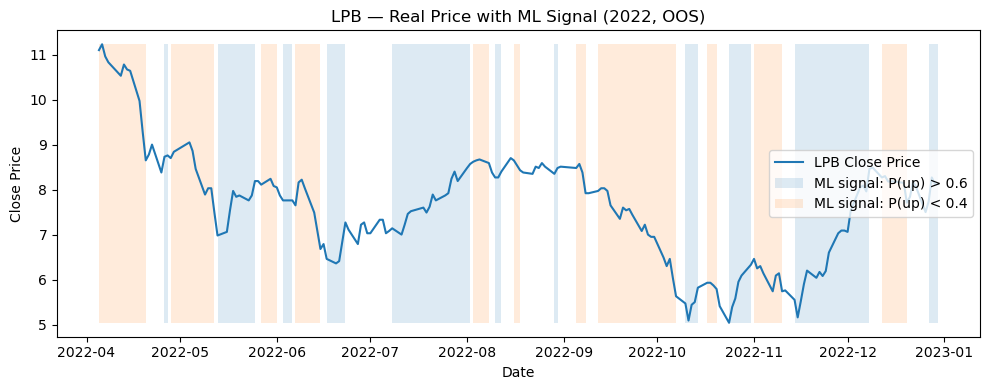

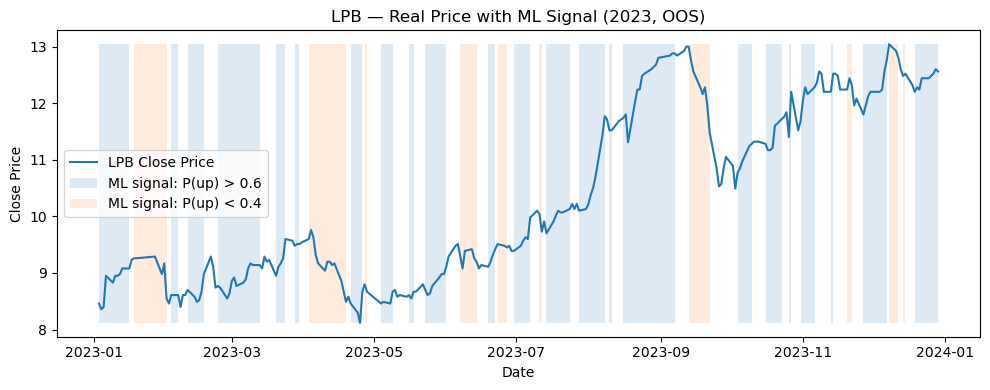

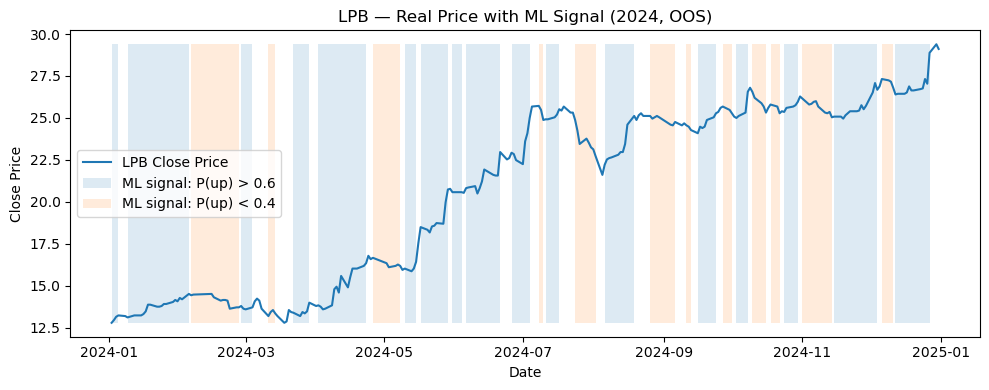

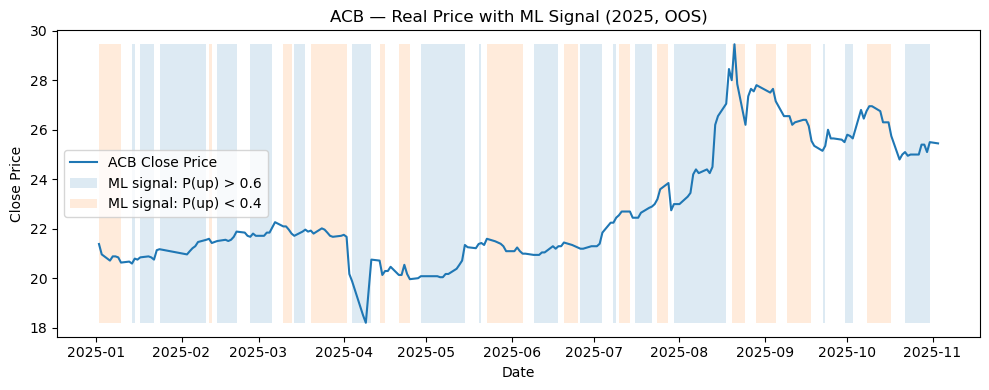

In [38]:
plot_price_with_signal("LPB", year=2022)
plot_price_with_signal("LPB", year=2023)
plot_price_with_signal("LPB", year=2024)
plot_price_with_signal("ACB", year=2025)

# Predict 2026 (Volume)

In [26]:
K_2026 = 60   # số ngày dùng để đo độ ổn định

snapshot_dates = X.index[-K_2026:]

print("Using snapshots from:",
      snapshot_dates.min(), "→", snapshot_dates.max())

Using snapshots from: 2025-08-08 00:00:00 → 2025-11-03 00:00:00


In [27]:
symbols = [c.replace("y5cls_", "") for c in y.columns]

P_sum = pd.Series(0.0, index=symbols)
P_sq  = pd.Series(0.0, index=symbols)

In [28]:
for d in snapshot_dates:
    X_d = X.loc[[d]]  # 1 snapshot

    proba = final_model.predict_proba(X_d)

    # lấy xác suất P(up) cho từng mã
    P_d = pd.Series(
        [p[0, 1] for p in proba],
        index=symbols
    )

    P_sum += P_d
    P_sq  += P_d ** 2

In [29]:
avg_P_up = P_sum / K_2026
std_P_up = np.sqrt(P_sq / K_2026 - avg_P_up**2)

In [30]:
leader_2026 = pd.DataFrame({
    "avg_P_up": avg_P_up,
    "std_P_up": std_P_up
}).sort_values(
    ["avg_P_up", "std_P_up"],
    ascending=[False, True]
)

print("🔮 ML STABILITY FORECAST — 2026")
print(leader_2026.head(10))

print("\n🏆 PREDICTED LEADER 2026:", leader_2026.index[0])

🔮 ML STABILITY FORECAST — 2026
     avg_P_up  std_P_up
LPB  0.583333  0.493007
STB  0.550000  0.497494
CTG  0.550000  0.497494
TCB  0.516667  0.499722
HDB  0.516667  0.499722
VRE  0.516667  0.499722
VHM  0.483333  0.499722
MWG  0.483333  0.499722
SHB  0.450000  0.497494
ACB  0.450000  0.497494

🏆 PREDICTED LEADER 2026: LPB


In [46]:
!pip install adjustText

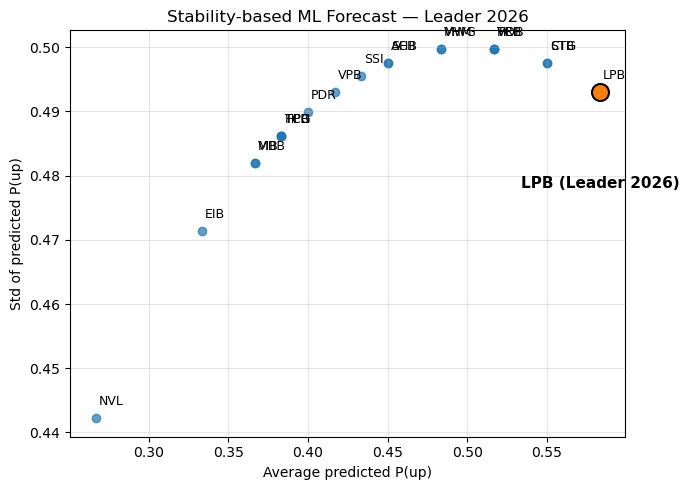

In [46]:
import matplotlib.pyplot as plt

df = leader_2026.copy()

plt.figure(figsize=(7, 5))

# Scatter toàn bộ cổ phiếu
plt.scatter(
    df["avg_P_up"],
    df["std_P_up"],
    alpha=0.7
)

# Annotate từng mã
for sym, row in df.iterrows():
    plt.text(
        row["avg_P_up"] + 0.002,
        row["std_P_up"] + 0.002,
        sym,
        fontsize=9
    )

# Highlight LPB
plt.scatter(
    df.loc["LPB", "avg_P_up"],
    df.loc["LPB", "std_P_up"],
    s=150,
    edgecolors="black",
    linewidths=1.5
)
plt.text(
    df.loc["LPB", "avg_P_up"],
    df.loc["LPB", "std_P_up"] - 0.015,
    "LPB (Leader 2026)",
    fontsize=11,
    fontweight="bold",
    ha="center"
)

plt.xlabel("Average predicted P(up)")
plt.ylabel("Std of predicted P(up)")
plt.title("Stability-based ML Forecast — Leader 2026")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

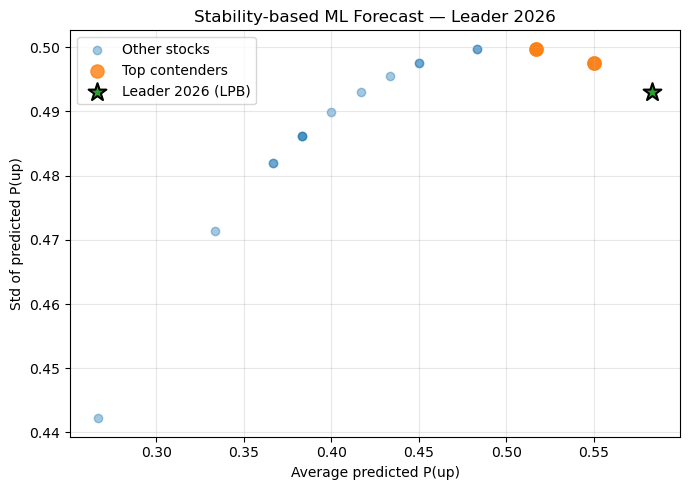

In [47]:
import matplotlib.pyplot as plt

df = leader_2026.copy()

leader = "LPB"
top_k = 5
top_syms = df.head(top_k).index.tolist()

plt.figure(figsize=(7, 5))

# Others
others = df.index.difference(top_syms)
plt.scatter(
    df.loc[others, "avg_P_up"],
    df.loc[others, "std_P_up"],
    alpha=0.4,
    label="Other stocks"
)

# Top contenders (excluding leader)
top_others = [s for s in top_syms if s != leader]
plt.scatter(
    df.loc[top_others, "avg_P_up"],
    df.loc[top_others, "std_P_up"],
    s=90,
    alpha=0.8,
    label="Top contenders"
)

# Leader
plt.scatter(
    df.loc[leader, "avg_P_up"],
    df.loc[leader, "std_P_up"],
    s=180,
    marker="*",
    edgecolors="black",
    linewidths=1.5,
    label="Leader 2026 (LPB)"
)

plt.xlabel("Average predicted P(up)")
plt.ylabel("Std of predicted P(up)")
plt.title("Stability-based ML Forecast — Leader 2026")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# VOLATILITY

## Imports & Paths

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis

PATH_DATA  = r"C:/Users/nhokk/Downloads/FINAL DATASET.xlsx"
PATH_PMIME = r"C:/Users/nhokk/Downloads/PMIME_features_for_python.csv"
PATH_CGCI  = r"C:/Users/nhokk/Downloads/cgci_node_scores_top20volatility_2021_2024.csv"

## SELECT 20 STOCKS VOLATILITY

In [2]:
import pandas as pd
import numpy as np

file_path = "FINAL DATASET.xlsx"
df_raw = pd.read_excel(file_path)

df = df_raw.copy()
df.columns = [c.lower() for c in df.columns]

df["time"]   = pd.to_datetime(df["time"])
df["symbol"] = df["symbol"].astype(str).str.upper().str.strip()

# Keep data from 2021-03-24 onward
df = df[df["time"] >= "2021-03-24"].copy()

# Remove ROS
df = df[df["symbol"] != "ROS"].copy()

# Remove duplicate observations (time, symbol)
df = df.sort_values(["time", "symbol"]) \
       .drop_duplicates(subset=["time", "symbol"], keep="first") \
       .copy()

print("✅ Clean df shape:", df.shape)
print("✅ Time range:", df["time"].min(), "→", df["time"].max())
print("✅ Number of symbols:", df["symbol"].nunique())


# FIXED UNIVERSE (20 STOCKS)
FIXED_SYMBOLS = [
    'TCH','GVR','PDR','SSI','NVL','DGC','EIB','LPB','SHB','STB',
    'VRE','SBT','MSN','KDH','MWG','BCM','HPG','TPB','VIC','VHM'
]

# Check presence in df
present = sorted([s for s in FIXED_SYMBOLS if s in df["symbol"].unique()])
missing = sorted([s for s in FIXED_SYMBOLS if s not in df["symbol"].unique()])

print("\n📌 Fixed universe (20 stocks):")
print(FIXED_SYMBOLS)
print("→ Total:", len(FIXED_SYMBOLS))

print("\n✅ Present in df:", present)
print("❌ Missing in df:", missing)


# RETURNS & VOLATILITY
prices = df.pivot(index="time", columns="symbol", values="close").sort_index()
log_returns = np.log(prices).diff().dropna(how="all")

# Restrict to fixed universe (robust, no KeyError)
logret_stocks = log_returns.reindex(columns=FIXED_SYMBOLS).copy()

# Volatility (std of daily log-returns)
vol_stats = logret_stocks.std(ddof=1, skipna=True).sort_values(ascending=False)

print("\n📊 Volatility ranking (fixed universe):")
print(vol_stats)

✅ Clean df shape: (47475, 9)
✅ Time range: 2021-03-24 00:00:00 → 2025-11-10 00:00:00
✅ Number of symbols: 41

📌 Fixed universe (20 stocks):
['TCH', 'GVR', 'PDR', 'SSI', 'NVL', 'DGC', 'EIB', 'LPB', 'SHB', 'STB', 'VRE', 'SBT', 'MSN', 'KDH', 'MWG', 'BCM', 'HPG', 'TPB', 'VIC', 'VHM']
→ Total: 20

✅ Present in df: ['BCM', 'DGC', 'EIB', 'GVR', 'HPG', 'KDH', 'LPB', 'MSN', 'MWG', 'NVL', 'PDR', 'SBT', 'SHB', 'SSI', 'STB', 'TCH', 'TPB', 'VHM', 'VIC', 'VRE']
❌ Missing in df: []

📊 Volatility ranking (fixed universe):
symbol
TCH    0.029711
GVR    0.028046
PDR    0.027269
SSI    0.026762
NVL    0.026630
DGC    0.025876
EIB    0.025280
LPB    0.024593
SHB    0.024236
STB    0.024117
VRE    0.023258
SBT    0.022973
MSN    0.022575
KDH    0.022186
MWG    0.022116
BCM    0.021617
HPG    0.021542
TPB    0.021524
VIC    0.021380
VHM    0.021011
dtype: float64


## Technical features

In [3]:
prices = df.pivot(index="time", columns="symbol", values="close").sort_index()
prices = prices[FIXED_SYMBOLS].copy()
log_p = np.log(prices)

ret1 = log_p.diff().add_prefix("ret1_")
ret5 = (log_p.shift(-5) - log_p).add_prefix("y5_")   # TARGET (forward 5d log-return)

mom5  = log_p.diff(5).add_prefix("mom5_")
mom10 = log_p.diff(10).add_prefix("mom10_")
mom20 = log_p.diff(20).add_prefix("mom20_")

ma7  = ret1.rolling(7).mean().add_prefix("ma7_")
ma14 = ret1.rolling(14).mean().add_prefix("ma14_")
ma21 = ret1.rolling(21).mean().add_prefix("ma21_")

vol7  = ret1.rolling(7).std().add_prefix("vol7_")
vol14 = ret1.rolling(14).std().add_prefix("vol14_")
vol21 = ret1.rolling(21).std().add_prefix("vol21_")

vol_ratio = (vol7 / (vol21 + 1e-8))
vol_ratio.columns = [c.replace("vol7_", "volratio_") for c in vol_ratio.columns]

def rolling_apply(df_in, w, func, pre):
    out = pd.DataFrame(index=df_in.index, columns=df_in.columns, dtype="float64")
    for c in df_in.columns:
        out[c] = df_in[c].rolling(w).apply(func, raw=False)
    return out.add_prefix(pre)

skew7  = rolling_apply(ret1, 7,  skew,     "skew7_")
skew14 = rolling_apply(ret1, 14, skew,     "skew14_")
kurt7  = rolling_apply(ret1, 7,  kurtosis, "kurt7_")
kurt14 = rolling_apply(ret1, 14, kurtosis, "kurt14_")

In [4]:
# volume features
df_vol = df[df["volume"] > 0].copy().sort_values(["symbol","time"])
df_vol["log_volume"] = np.log(df_vol["volume"])
df_vol["log_vol_return"] = df_vol.groupby("symbol")["log_volume"].diff()

vol_mat = df_vol.pivot(index="time", columns="symbol", values="log_vol_return")
vol_mat = vol_mat[FIXED_SYMBOLS].reindex(prices.index).add_prefix("volret_")

vol_raw = df_vol.pivot(index="time", columns="symbol", values="volume")
vol_raw = vol_raw[FIXED_SYMBOLS].reindex(prices.index)

vol_ma7  = vol_raw.rolling(7).mean().add_prefix("volma7_")
vol_ma14 = vol_raw.rolling(14).mean().add_prefix("volma14_")
vol_std7 = vol_raw.rolling(7).std().add_prefix("volstd7_")

# order matrix (nếu có)
order_mat = None
if "order" in df.columns:
    order_mat = df.pivot(index="time", columns="symbol", values="order")
    order_mat = order_mat[FIXED_SYMBOLS].reindex(prices.index).add_prefix("ord_")

# usdreturn (nếu có)
usd_series = None
if "usdreturn" in df.columns:
    usd_series = df.groupby("time")["usdreturn"].first().reindex(prices.index).rename("usdreturn")

## Load causal features (PMIME + CGCI), merge, broadcast by day

In [5]:
pmime = pd.read_csv(PATH_PMIME)
cgci  = pd.read_csv(PATH_CGCI)

pmime["symbol"] = pmime["symbol"].astype(str).str.upper()
cgci["symbol"]  = cgci["symbol"].astype(str).str.upper()

# chỉ lấy các mã thuộc top20
pmime = pmime[pmime["symbol"].isin(FIXED_SYMBOLS)].copy()
cgci  = cgci[cgci["symbol"].isin(FIXED_SYMBOLS)].copy()

# merge 2 bảng theo symbol
causal = pd.merge(pmime, cgci, on="symbol", how="outer")

# fill missing (phòng trường hợp thiếu mã ở pmime)
for c in causal.columns:
    if c != "symbol":
        causal[c] = pd.to_numeric(causal[c], errors="coerce")
causal = causal.fillna(0)

print("✅ Causal table (symbol-level):", causal.shape)
print(causal.head())

# broadcast causal features ra theo ngày: tạo DataFrame index=time, columns=feature_symbol
causal_index = prices.index

causal_wide_list = []
feat_cols = [c for c in causal.columns if c != "symbol"]

for f in feat_cols:
    s = causal.set_index("symbol")[f].reindex(FIXED_SYMBOLS)
    wide = pd.DataFrame(
        np.tile(s.values, (len(causal_index), 1)),
        index=causal_index,
        columns=[f"{f}_{sym}" for sym in FIXED_SYMBOLS]
    )
    causal_wide_list.append(wide)

causal_wide = pd.concat(causal_wide_list, axis=1)

# (khuyến nghị) shift 1 ngày để “an toàn” chống leak theo thời gian
# nếu bạn muốn giữ nguyên thì comment dòng dưới
causal_wide = causal_wide.shift(1)

print("✅ causal_wide:", causal_wide.shape)

✅ Causal table (symbol-level): (20, 14)
  symbol  pmime_out  pmime_in  pmime_net  deg_out  deg_in  deg_net  \
0    BCM   0.000000  0.000000   0.000000      0.0     0.0      0.0   
1    DGC   0.000000  0.000000   0.000000      0.0     0.0      0.0   
2    EIB   2.080983  1.668045   0.412938     11.0    11.0      0.0   
3    GVR   0.000000  0.000000   0.000000      0.0     0.0      0.0   
4    HPG   2.560431  1.461456   1.098975     13.0     9.0      4.0   

   betweenness  eigenvector  pagerank  community_id  out_degree  in_degree  \
0     0.000000     0.000000  0.000000           0.0           0          0   
1     0.000000     0.000000  0.000000           0.0           1          0   
2     9.437302     0.049319  0.048864           1.0           4          0   
3     0.000000     0.000000  0.000000           0.0           1          1   
4    29.993407     0.059180  0.049602           1.0           3          4   

   net_degree  
0           0  
1           1  
2           4  
3     

## Build dataset_full (features + target)

In [6]:
parts = [
    ret1,
    mom5, mom10, mom20,
    ma7, ma14, ma21,
    vol7, vol14, vol21,
    vol_ratio,
    skew7, skew14,
    kurt7, kurt14,
    vol_mat, vol_ma7, vol_ma14, vol_std7,
    order_mat,
    usd_series,
    causal_wide,   
    ret5
]

print("✅ parts defined:", len(parts))


✅ parts defined: 23


In [7]:
# 5.1) Concat tất cả parts (KHÔNG dropna vội)
dataset_full = pd.concat(parts, axis=1)

print("Before cleaning:", dataset_full.shape)
print("Index range:", dataset_full.index.min(), "->", dataset_full.index.max())

# 5.2) Chỉ drop theo TARGET (y5_) vì nếu không có target thì không train được
ycols = [c for c in dataset_full.columns if c.startswith("y5_")]
if len(ycols) == 0:
    raise ValueError("Không thấy cột target y5_. Kiểm tra ret5 tạo đúng chưa.")

dataset_full = dataset_full.dropna(subset=ycols).copy()

print("After dropna(target):", dataset_full.shape)
print("Index range:", dataset_full.index.min(), "->", dataset_full.index.max())

# 5.3) Fill NA cho FEATURES (khuyến nghị cho tree models)
# Nếu bạn muốn nghiêm ngặt hơn: có thể ffill theo thời gian trước rồi fill 0
dataset_full = dataset_full.sort_index()
dataset_full = dataset_full.fillna(method="ffill").fillna(0)

# 5.4) Sanity checks
assert len(dataset_full) > 0, "❌ dataset_full vẫn rỗng sau khi xử lý!"
assert dataset_full.index.is_monotonic_increasing, "❌ Index thời gian không tăng dần!"
assert dataset_full.index.is_unique, "❌ Index bị trùng!"

# check đủ target cho top20
missing_targets = [f"y5_{sym}" for sym in FIXED_SYMBOLS
                   if f"y5_{sym}" not in dataset_full.columns]
if missing_targets:
    raise ValueError(f"❌ Thiếu target cho các mã: {missing_targets}")

# check causal cols có tồn tại
causal_cols = [c for c in dataset_full.columns if c.startswith("cgci_") or c.startswith("pmime_")]
print("✅ #causal cols:", len(causal_cols))
print("✅ dataset_full:", dataset_full.shape)
print("✅ Date range:", dataset_full.index.min(), "->", dataset_full.index.max())

Before cleaning: (1158, 701)
Index range: 2021-03-24 00:00:00 -> 2025-11-10 00:00:00
After dropna(target): (1147, 701)
Index range: 2021-03-24 00:00:00 -> 2025-11-03 00:00:00
✅ #causal cols: 60
✅ dataset_full: (1147, 701)
✅ Date range: 2021-03-24 00:00:00 -> 2025-11-03 00:00:00


C:\Users\nhokk\AppData\Local\Temp\ipykernel_21524\2190156243.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dataset_full = dataset_full.fillna(method="ffill").fillna(0)


## Build binary target y5cls_ (classification) - y5cls = 1 if forward 5d log return > 0 else 0

In [8]:
# target log-return 5 ngày
ycols = [c for c in dataset_full.columns if c.startswith("y5_")]

y_bin = (dataset_full[ycols] > 0).astype(int)
y_bin.columns = [c.replace("y5_", "y5cls_") for c in y_bin.columns]

# feature matrix
X = dataset_full.drop(columns=ycols)
y = y_bin.copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1147, 681)
y shape: (1147, 20)


## Model factories (ET vs RF)

In [9]:
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier

def make_et():
    return ExtraTreesClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )

def make_rf():
    return RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )

print("✅ Model factories ready")

✅ Model factories ready


In [10]:
# OOS prediction for model comparison
def oos_predict(model_maker, X, y, min_train=252):
    P_list = []
    dates = []

    for i in range(min_train, len(X)):
        X_tr = X.iloc[:i]
        y_tr = y.iloc[:i]
        X_te = X.iloc[[i]]

        model = model_maker()
        model.fit(X_tr, y_tr)

        proba = model.predict_proba(X_te)
        p1 = [p[0,1] for p in proba]

        P_list.append(p1)
        dates.append(X.index[i])

    return pd.DataFrame(
        P_list,
        index=dates,
        columns=[c.replace("y5cls_", "") for c in y.columns]
    )

In [11]:
P_ET = oos_predict(make_et, X, y)
P_RF = oos_predict(make_rf, X, y)

print("ET OOS shape:", P_ET.shape)
print("RF OOS shape:", P_RF.shape)

ET OOS shape: (895, 20)
RF OOS shape: (895, 20)


In [12]:
# target thực tế
y_true = y.loc[P_ET.index]
y_true.columns = [c.replace("y5cls_", "") for c in y_true.columns]

# Brier loss (trung bình cross-section mỗi ngày)
loss_ET = ((P_ET - y_true) ** 2).mean(axis=1)
loss_RF = ((P_RF - y_true) ** 2).mean(axis=1)

print("Mean Brier loss ET:", loss_ET.mean())
print("Mean Brier loss RF:", loss_RF.mean())

Mean Brier loss ET: 0.17003459466170082
Mean Brier loss RF: 0.1860984400993172


## Model selection: Brier loss + DM-style t-test

In [13]:
from scipy import stats

d = loss_RF - loss_ET   # >0 ⇒ ET tốt hơn
t_stat, p_value = stats.ttest_1samp(d, 0)

print("DM t-stat :", t_stat)
print("p-value   :", p_value)

DM t-stat : 24.29183992162666
p-value   : 1.699718077088044e-100


## Build P_up_oos using ExtraTrees (for charts/leader backtest)

In [14]:
from sklearn.ensemble import ExtraTreesClassifier

P_up_oos = []   # out-of-sample probabilities
dates_oos = []

min_train = 252   # ~1 năm giao dịch

for i in range(min_train, len(X)):
    X_train = X.iloc[:i]
    y_train = y.iloc[:i]

    X_test  = X.iloc[[i]]

    model = ExtraTreesClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    proba = model.predict_proba(X_test)
    p1 = [p[0,1] for p in proba]

    P_up_oos.append(p1)
    dates_oos.append(X.index[i])

P_up_oos = pd.DataFrame(
    P_up_oos,
    index=dates_oos,
    columns=[c.replace("y5cls_", "") for c in y.columns]
)

print("✅ P_up_oos shape:", P_up_oos.shape)
P_up_oos.head()

✅ P_up_oos shape: (895, 20)


,TCH,GVR,PDR,SSI,NVL,DGC,EIB,LPB,SHB,STB,VRE,SBT,MSN,KDH,MWG,BCM,HPG,TPB,VIC,VHM
2022-04-05,0.166667,0.386667,0.286667,0.366667,0.383333,0.283333,0.200000,0.326667,0.203333,0.270000,0.240000,0.243333,0.810000,0.263333,0.343333,0.713333,0.373333,0.326667,0.186667,0.223333
2022-04-06,0.206667,0.263333,0.253333,0.303333,0.280000,0.593333,0.216667,0.210000,0.153333,0.170000,0.170000,0.236667,0.833333,0.210000,0.620000,0.686667,0.253333,0.240000,0.156667,0.170000
2022-04-07,0.186667,0.273333,0.263333,0.286667,0.273333,0.673333,0.200000,0.240000,0.200000,0.240000,0.230000,0.256667,0.573333,0.270000,0.673333,0.686667,0.293333,0.330000,0.440000,0.200000
2022-04-08,0.260000,0.343333,0.373333,0.310000,0.356667,0.760000,0.256667,0.326667,0.273333,0.283333,0.293333,0.320000,0.483333,0.280000,0.720000,0.636667,0.350000,0.443333,0.550000,0.273333
2022-04-12,0.200000,0.636667,0.263333,0.293333,0.276667,0.703333,0.216667,0.280000,0.336667,0.290000,0.220000,0.330000,0.780000,0.313333,0.746667,0.626667,0.330000,0.410000,0.290000,0.240000


## Realized 5d simple return (for leader contribution scoring)

In [15]:
# ycols = target log-return 5 ngày
ycols = [c for c in dataset_full.columns if c.startswith("y5_")]

ret5_simple = np.exp(dataset_full[ycols]) - 1
ret5_simple.columns = [c.replace("y5_", "") for c in ret5_simple.columns]

print("✅ ret5_simple:", ret5_simple.shape, ret5_simple.index.min(), "->", ret5_simple.index.max())

✅ ret5_simple: (1147, 20) 2021-03-24 00:00:00 -> 2025-11-03 00:00:00


## OOS Leaders 2021–2024

In [16]:
leader_results = {}

for yr in [2021, 2022, 2023, 2024]:
    idx = P_up_oos.index[P_up_oos.index.year == yr]  

    P = P_up_oos.loc[idx]
    R = ret5_simple.loc[idx]                          

    picks = P.idxmax(axis=1)

    contrib = pd.Series(0.0, index=P.columns)
    for t, sym in picks.items():
        contrib[sym] += R.loc[t, sym]

    leader = contrib.sort_values(ascending=False)
    leader_results[yr] = leader

    print(f"\n🏆 PREDICTED LEADER {yr} (OOS)")
    print(leader.head(5))


🏆 PREDICTED LEADER 2021 (OOS)
TCH    0.0
GVR    0.0
PDR    0.0
SSI    0.0
NVL    0.0
dtype: float64

🏆 PREDICTED LEADER 2022 (OOS)
DGC    1.703973
KDH    0.817949
EIB    0.766191
MWG    0.708769
SSI    0.659052
dtype: float64

🏆 PREDICTED LEADER 2023 (OOS)
LPB    1.468753
SSI    0.988582
HPG    0.835112
DGC    0.802126
NVL    0.662000
dtype: float64

🏆 PREDICTED LEADER 2024 (OOS)
LPB    2.417727
DGC    1.321757
STB    0.713878
GVR    0.489478
BCM    0.264390
dtype: float64


## Train final model on FULL sample (2021–2024)

In [17]:
from sklearn.ensemble import ExtraTreesClassifier

final_model = ExtraTreesClassifier(
    n_estimators=600,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X, y)
print("✅ Final ExtraTrees model trained (2021–2024)")

✅ Final ExtraTrees model trained (2021–2024)


## Robust ML forecast for 2025

In [18]:
K = 20  # số ngày cuối 2024
snapshots_2025 = X.index[-K:]

scores_2025 = pd.Series(0.0, index=[c.replace("y5cls_", "") for c in y.columns])

for d in snapshots_2025:
    X_d = X.loc[[d]]
    proba_d = final_model.predict_proba(X_d)

    P_d = pd.Series(
        [p[0,1] for p in proba_d],
        index=scores_2025.index
    )

    scores_2025 += P_d

# Trung bình xác suất
scores_2025 = (scores_2025 / K).sort_values(ascending=False)

print("🔮 ML FORECAST — LEADER SIGNALS 2025 (ROBUST)")
print(scores_2025.head(10))

print("\n🏆 PREDICTED LEADER 2025:", scores_2025.index[0])

🔮 ML FORECAST — LEADER SIGNALS 2025 (ROBUST)
VIC    0.60
DGC    0.60
BCM    0.55
KDH    0.55
SBT    0.50
GVR    0.50
MWG    0.45
MSN    0.40
SHB    0.35
LPB    0.30
dtype: float64

🏆 PREDICTED LEADER 2025: VIC


## Charts with Probability

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_price_with_signal(sym, year=2024, hi=0.6, lo=0.4):
    # Chỉ lấy 1 năm cho dễ nhìn
    idx = P_up_oos.index[P_up_oos.index.year == year]

    price = prices.loc[idx, sym]
    p_up  = P_up_oos.loc[idx, sym]

    plt.figure(figsize=(10, 4))
    plt.plot(price.index, price.values, label=f"{sym} Close Price")

    y_min, y_max = price.min(), price.max()

    # Tô nền theo tín hiệu ML
    plt.fill_between(
        price.index, y_min, y_max,
        where=(p_up > hi),
        alpha=0.15,
        label="ML signal: P(up) > 0.6"
    )

    plt.fill_between(
        price.index, y_min, y_max,
        where=(p_up < lo),
        alpha=0.15,
        label="ML signal: P(up) < 0.4"
    )

    plt.title(f"{sym} — Real Price with ML Signal ({year}, OOS)")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.legend()
    plt.tight_layout()
    plt.show()

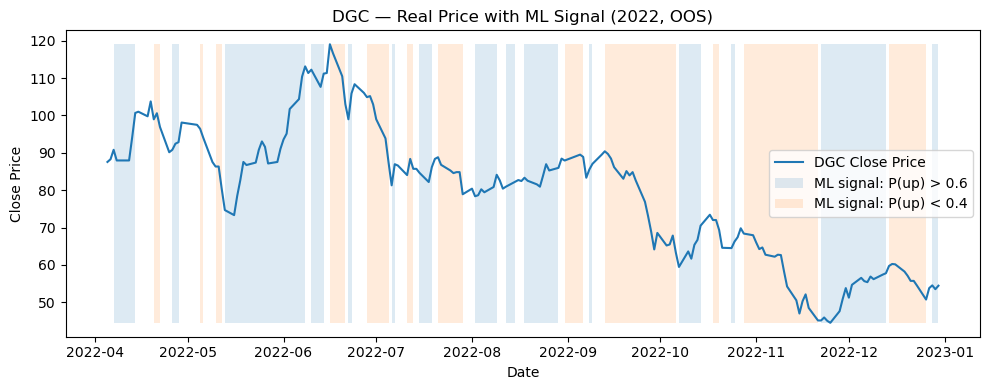

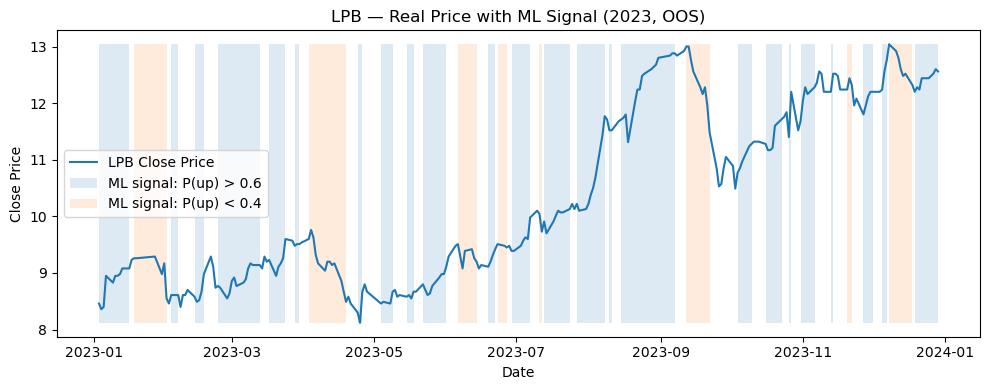

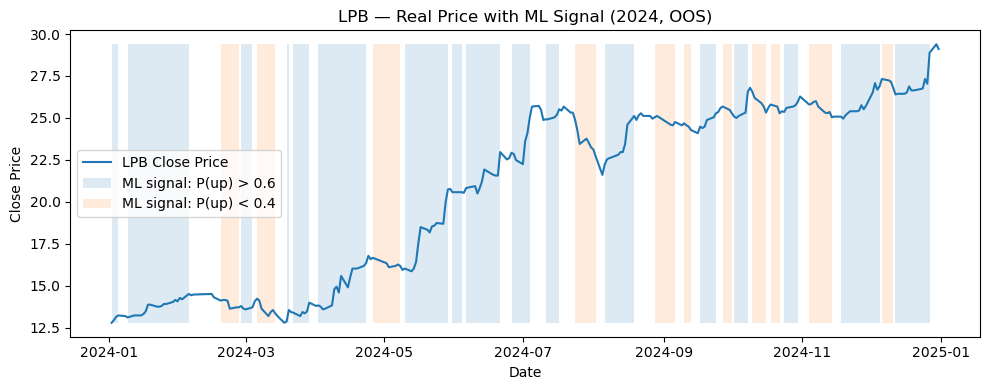

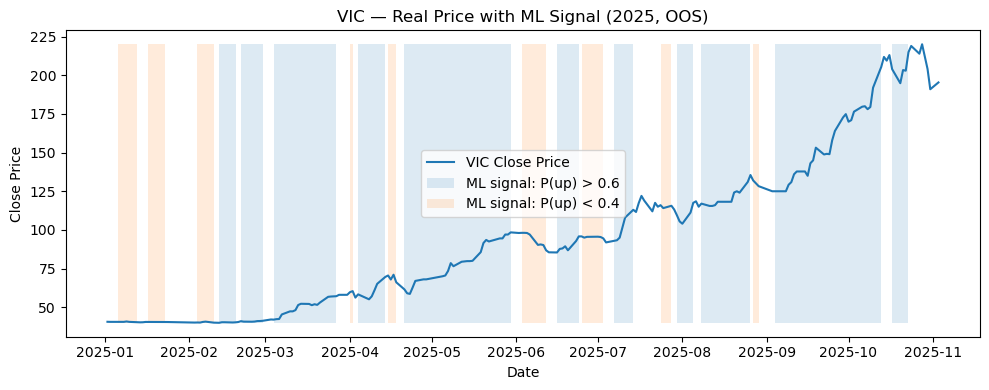

In [28]:
plot_price_with_signal("DGC", year=2022)
plot_price_with_signal("LPB", year=2023)
plot_price_with_signal("LPB", year=2024)
plot_price_with_signal("VIC", year=2025)

# Predict 2026 (Volatility)

In [21]:
K_2026 = 60   # số ngày dùng để đo độ ổn định

snapshot_dates = X.index[-K_2026:]

print("Using snapshots from:",
      snapshot_dates.min(), "→", snapshot_dates.max())

Using snapshots from: 2025-08-08 00:00:00 → 2025-11-03 00:00:00


In [22]:
symbols = [c.replace("y5cls_", "") for c in y.columns]

P_sum = pd.Series(0.0, index=symbols)
P_sq  = pd.Series(0.0, index=symbols)

In [23]:
for d in snapshot_dates:
    X_d = X.loc[[d]]  # 1 snapshot

    proba = final_model.predict_proba(X_d)

    # lấy xác suất P(up) cho từng mã
    P_d = pd.Series(
        [p[0, 1] for p in proba],
        index=symbols
    )

    P_sum += P_d
    P_sq  += P_d ** 2

In [24]:
avg_P_up = P_sum / K_2026
std_P_up = np.sqrt(P_sq / K_2026 - avg_P_up**2)

In [25]:
leader_2026 = pd.DataFrame({
    "avg_P_up": avg_P_up,
    "std_P_up": std_P_up
}).sort_values(
    ["avg_P_up", "std_P_up"],
    ascending=[False, True]
)

print("🔮 ML STABILITY FORECAST — 2026")
print(leader_2026.head(10))

print("\n🏆 PREDICTED LEADER 2026:", leader_2026.index[0])

🔮 ML STABILITY FORECAST — 2026
     avg_P_up  std_P_up
VIC  0.800000  0.400000
LPB  0.583333  0.493007
STB  0.550000  0.497494
VRE  0.516667  0.499722
MWG  0.483333  0.499722
VHM  0.483333  0.499722
SHB  0.450000  0.497494
SSI  0.433333  0.495536
MSN  0.433333  0.495536
KDH  0.416667  0.493007

🏆 PREDICTED LEADER 2026: VIC


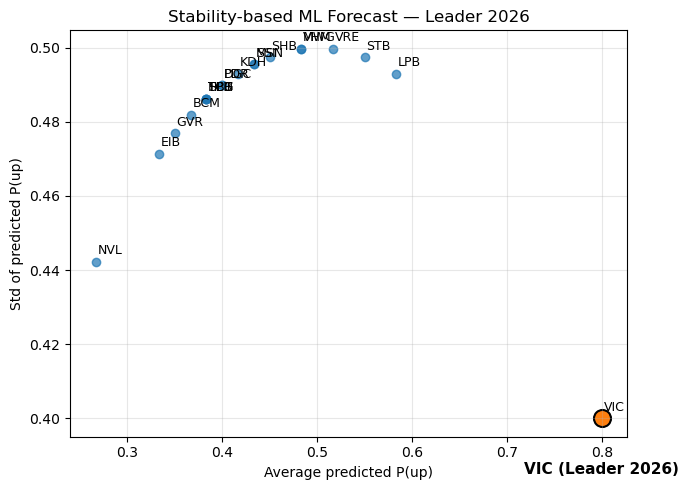

In [26]:
import matplotlib.pyplot as plt

df = leader_2026.copy()

plt.figure(figsize=(7, 5))

# Scatter toàn bộ cổ phiếu
plt.scatter(
    df["avg_P_up"],
    df["std_P_up"],
    alpha=0.7
)

# Annotate từng mã
for sym, row in df.iterrows():
    plt.text(
        row["avg_P_up"] + 0.002,
        row["std_P_up"] + 0.002,
        sym,
        fontsize=9
    )

# Highlight VIC
plt.scatter(
    df.loc["VIC", "avg_P_up"],
    df.loc["VIC", "std_P_up"],
    s=150,
    edgecolors="black",
    linewidths=1.5
)
plt.text(
    df.loc["VIC", "avg_P_up"],
    df.loc["VIC", "std_P_up"] - 0.015,
    "VIC (Leader 2026)",
    fontsize=11,
    fontweight="bold",
    ha="center"
)

plt.xlabel("Average predicted P(up)")
plt.ylabel("Std of predicted P(up)")
plt.title("Stability-based ML Forecast — Leader 2026")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

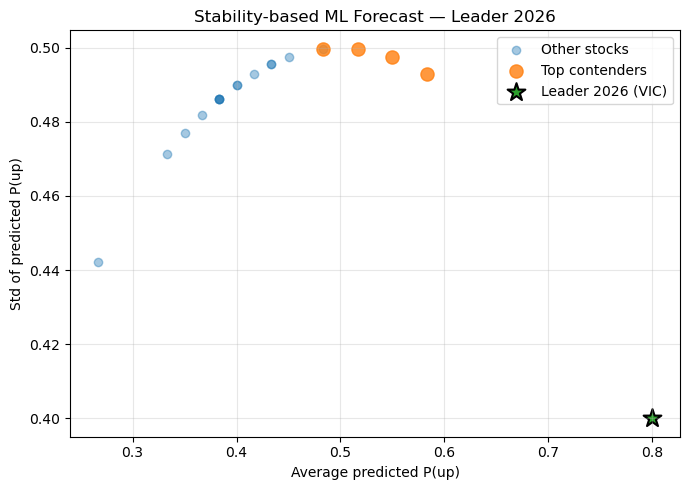

In [27]:
import matplotlib.pyplot as plt

df = leader_2026.copy()

leader = "VIC"
top_k = 5
top_syms = df.head(top_k).index.tolist()

plt.figure(figsize=(7, 5))

# Others
others = df.index.difference(top_syms)
plt.scatter(
    df.loc[others, "avg_P_up"],
    df.loc[others, "std_P_up"],
    alpha=0.4,
    label="Other stocks"
)

# Top contenders (excluding leader)
top_others = [s for s in top_syms if s != leader]
plt.scatter(
    df.loc[top_others, "avg_P_up"],
    df.loc[top_others, "std_P_up"],
    s=90,
    alpha=0.8,
    label="Top contenders"
)

# Leader
plt.scatter(
    df.loc[leader, "avg_P_up"],
    df.loc[leader, "std_P_up"],
    s=180,
    marker="*",
    edgecolors="black",
    linewidths=1.5,
    label="Leader 2026 (VIC)"
)

plt.xlabel("Average predicted P(up)")
plt.ylabel("Std of predicted P(up)")
plt.title("Stability-based ML Forecast — Leader 2026")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()